# AI Essay Detector
**Ziyad Alsalous** - January 2025


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, glob, string, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
SEED = 42

## Downloading the datasets
Using two kaggle datasets so we have more data to work with

In [2]:
import kagglehub

path1 = kagglehub.dataset_download('sunilthite/llm-detect-ai-generated-text-dataset')
path2 = kagglehub.dataset_download('jdragonxherrera/augmented-data-for-llm-detect-ai-generated-text')
print(path1, path2)

100%|██████████| 18.6M/18.6M [00:00<00:00, 66.7MB/s]

Extracting files...


100%|██████████| 314M/314M [00:05<00:00, 57.2MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/sunilthite/llm-detect-ai-generated-text-dataset/versions/1 /root/.cache/kagglehub/datasets/jdragonxherrera/augmented-data-for-llm-detect-ai-generated-text/versions/1


## Loading the data

Need to find all the csv files, figure out which columns are which since the datasets use different names, then merge everything together

In [3]:
# find all csvs in both folders
csv_files = glob.glob(os.path.join(path1,'**','*.csv'), recursive=True) + \
            glob.glob(os.path.join(path2,'**','*.csv'), recursive=True)

print(f'Found {len(csv_files)} csv files')
for f in csv_files:
    tmp = pd.read_csv(f, nrows=3)
    print(f'  {os.path.basename(f)} -> {tmp.columns.tolist()}')

Found 3 csv files
  Training_Essay_Data.csv -> ['text', 'generated']
  final_train.csv -> ['text', 'label']
  final_test.csv -> ['text', 'label']


In [4]:
def load_and_fix(filepath):
    """loads a csv and renames columns to text/generated so everything matches"""
    data = pd.read_csv(filepath)

# find text column
    txt_col = None
    for c in ['text','essay','content','essay_text']:
        if c in data.columns:
            txt_col = c
            break
    if txt_col is None:
        str_cols = data.select_dtypes(include='object').columns
        if len(str_cols) > 0:
            txt_col = data[str_cols].apply(lambda c: c.str.len().mean()).idxmax()
        else:
            return None

# find label column
    lbl_col = None
    for c in ['generated','label','is_generated','target','class']:
        if c in data.columns:
            lbl_col = c
            break
    if lbl_col is None:
        return None

    out = data[[txt_col, lbl_col]].copy()
    out.columns = ['text','generated']
    return out

### Merging it all

In [5]:
chunks = []
for f in csv_files:
    tmp = load_and_fix(f)
    if tmp is not None:
        chunks.append(tmp)

df = pd.concat(chunks, ignore_index=True)

df['generated'] = pd.to_numeric(df['generated'], errors='coerce')
df = df.dropna(subset=['generated'])
df['generated'] = df['generated'].astype(int)

print(f'Total rows: {len(df)}')
print(df['generated'].value_counts())

Total rows: 462709
generated
0    295507
1    167202
Name: count, dtype: int64


## Quick EDA

### Checking for missing values and duplicates

In [6]:
print(df[['text','generated']].isnull().sum())
print(f'\nDuplicate texts: {df.duplicated(subset="text").sum()}')
print(f'Empty texts: {df["text"].astype(str).str.strip().eq("").sum()}')

text         0
generated    0
dtype: int64

Duplicate texts: 4860
Empty texts: 0


### Class balance

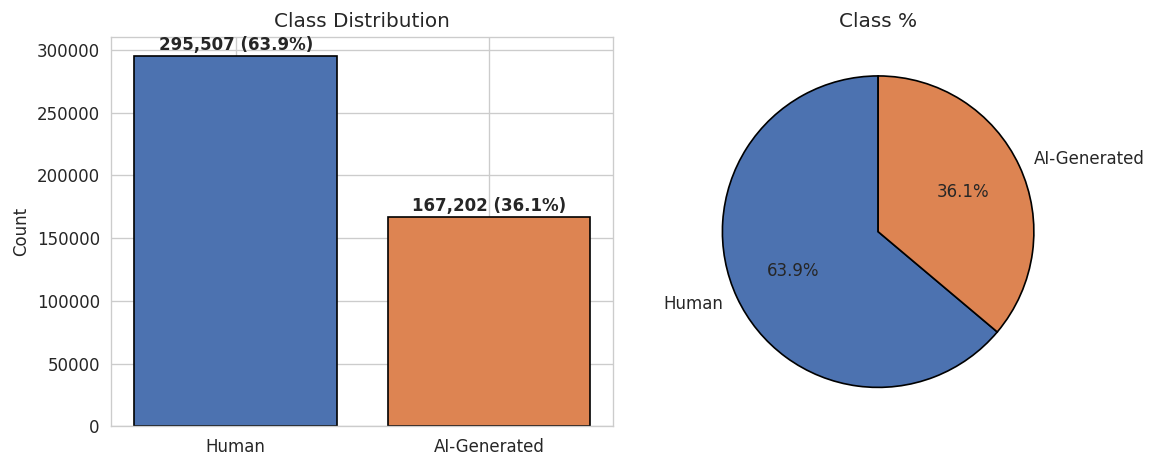

Balance ratio: 0.566  (Imbalanced)


In [7]:
labels = {0: 'Human', 1: 'AI-Generated'}
counts = df['generated'].value_counts().sort_index()

fig, axes = plt.subplots(1,2, figsize=(10,4))

bars = axes[0].bar([labels[i] for i in counts.index], counts.values,
                   color=['#4C72B0','#DD8452'], edgecolor='black')
for bar,val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+len(df)*0.01,
                f'{val:,} ({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=[labels[i] for i in counts.index],
           autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], startangle=90,
           wedgeprops={'edgecolor':'black'})
axes[1].set_title('Class %')

plt.tight_layout()
plt.show()

ratio = counts.min()/counts.max()
print(f'Balance ratio: {ratio:.3f}  ({"Balanced" if ratio > 0.8 else "Imbalanced"})')

### Text length distributions

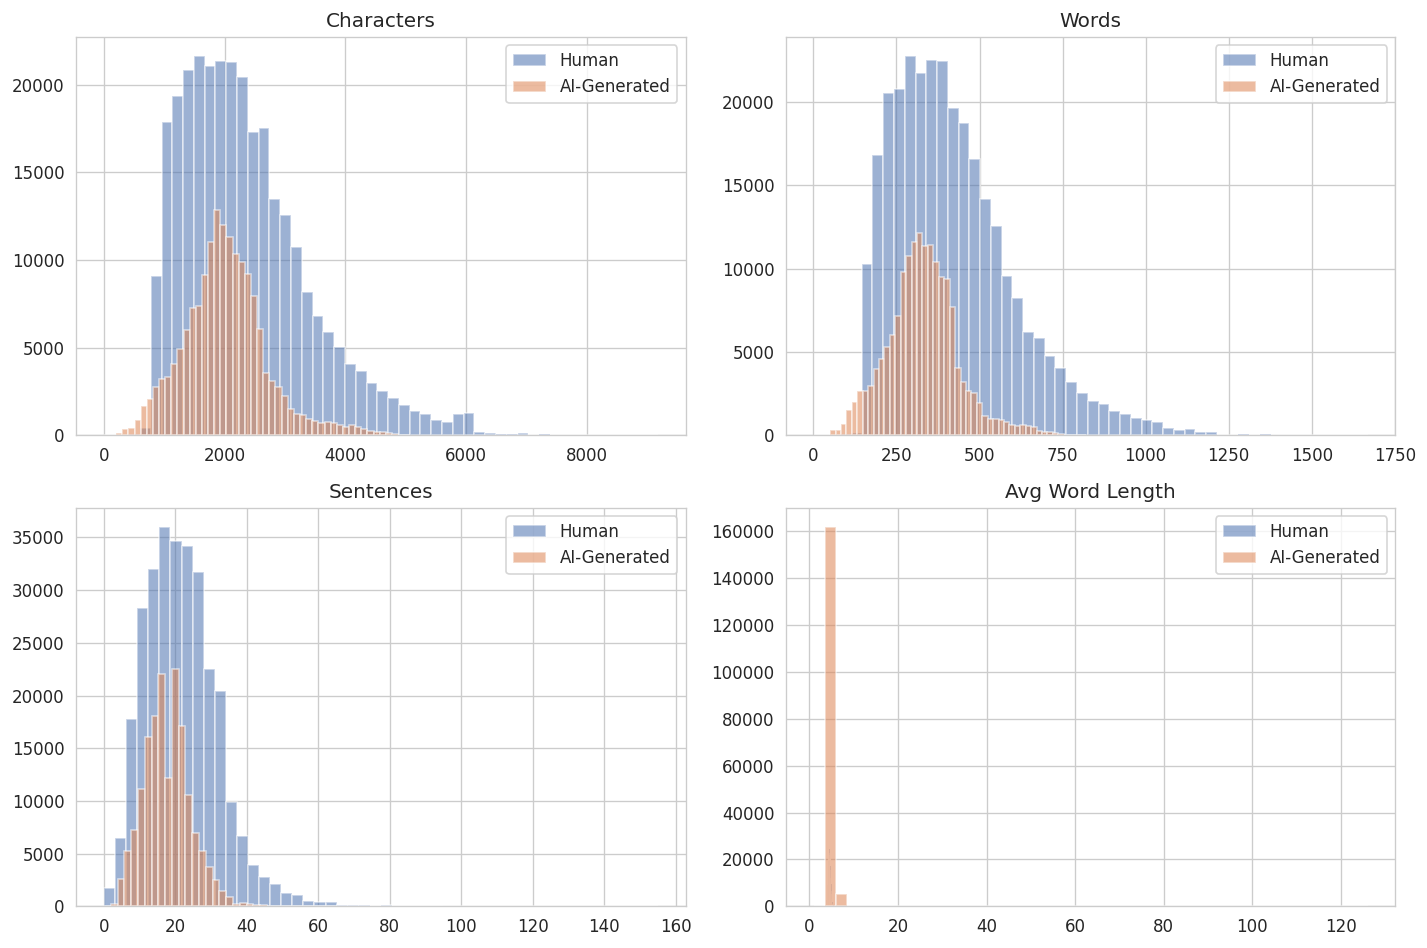

In [8]:
df['char_count'] = df['text'].astype(str).str.len()
df['word_count'] = df['text'].astype(str).str.split().str.len()
df['sent_count'] = df['text'].astype(str).str.count(r'[.!?]+')
df['avg_word_len'] = df['text'].astype(str).apply(
    lambda t: np.mean([len(w) for w in t.split()]) if len(t.split()) > 0 else 0
)

cols = ['char_count','word_count','sent_count','avg_word_len']
titles = ['Characters','Words','Sentences','Avg Word Length']

fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, col, t in zip(axes.flatten(), cols, titles):
    for lbl, clr in [(0,'#4C72B0'),(1,'#DD8452')]:
        ax.hist(df[df['generated']==lbl][col], bins=50, alpha=0.55, label=labels[lbl], color=clr, edgecolor='white')
    ax.set_title(t)
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
stats = df.groupby('generated')[cols].agg(['mean','median','std','min','max']).round(1)
stats.index = [labels[i] for i in stats.index]
stats

char_count                            word_count                \
                   mean  median     std  min   max       mean median    std   
Human            2354.3  2160.0  1077.0  239  9182      422.0  390.0  186.4   
AI-Generated     2016.7  1979.0   693.9    1  5078      329.6  327.0  106.5   

                       sent_count                       avg_word_len         \
             min   max       mean median   std min  max         mean median   
Human         48  1668       21.8   21.0  10.2   0  155          4.5    4.5   
AI-Generated   1   819       17.8   18.0   6.5   0   95          5.1    5.1   

                               
              std  min    max  
Human         0.3  3.1    6.3  
AI-Generated  0.6  1.0  126.0

### Punctuation and vocab diversity

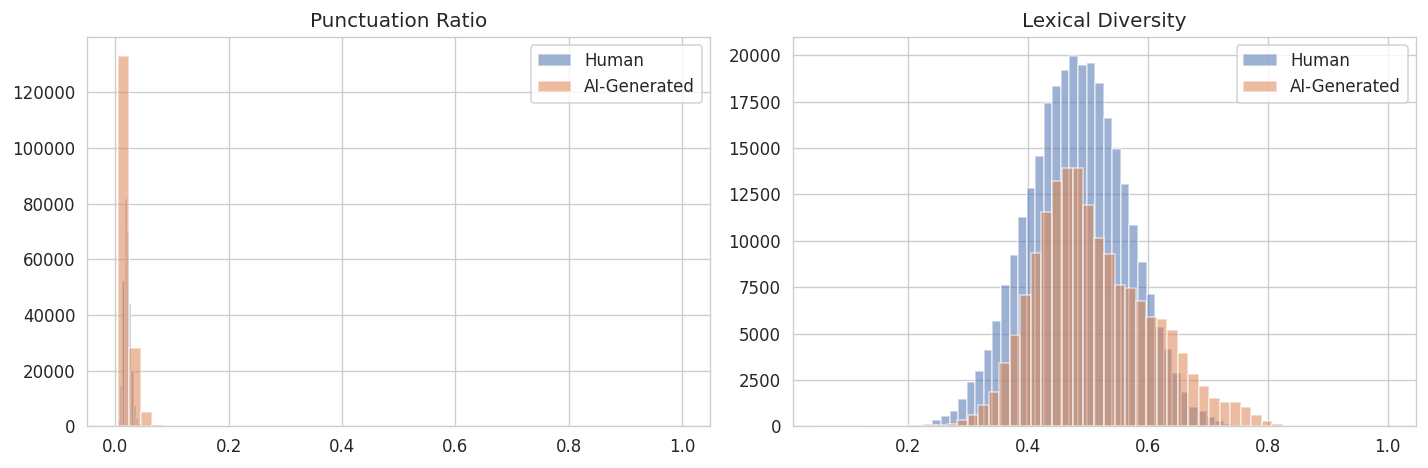

In [10]:
df['punct_ratio'] = df['text'].astype(str).apply(
    lambda t: sum(1 for c in t if c in string.punctuation) / max(len(t),1)
)
df['unique_word_ratio'] = df['text'].astype(str).apply(
    lambda t: len(set(t.lower().split())) / max(len(t.split()),1) if len(t.split())>0 else 0
)

fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax,col,t in zip(axes, ['punct_ratio','unique_word_ratio'], ['Punctuation Ratio','Lexical Diversity']):
    for lbl,clr in [(0,'#4C72B0'),(1,'#DD8452')]:
        ax.hist(df[df['generated']==lbl][col], bins=50, alpha=0.55, label=labels[lbl], color=clr, edgecolor='white')
    ax.set_title(t)
    ax.legend()
plt.tight_layout()
plt.show()

## Preprocessing

In [11]:
#drop dupes
before = len(df)
df = df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)
print(f'Dropped {before - len(df)} duplicates, {len(df)} remaining')

Dropped 4860 duplicates, 457849 remaining


In [12]:
#handle edge cases nulls, empty strings
before = len(df)
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str)
df = df[df['text'].str.strip().ne('')].reset_index(drop=True)

df['generated'] = df['generated'].astype(int)
df = df[df['generated'].isin([0,1])].reset_index(drop=True)
print(f'Cleaned out {before-len(df)} bad rows, {len(df)} left')

Cleaned out 0 bad rows, 457849 left


### Text cleaning
lowercase everything, remove urls and emails, strip out weird characters, collapse whitespace

In [13]:
def clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s.,!?;:\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean)

print('Before:', df['text'].iloc[0][:120])
print('After: ', df['text_clean'].iloc[0][:120])

#drop anything that ended up empty
empty = df['text_clean'].str.strip().eq('').sum()
if empty > 0:
    df = df[df['text_clean'].str.strip().ne('')].reset_index(drop=True)

Before: Car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world
After:  car-free cities have become a subject of increasing interest and debate in recent years, as urban areas around the world


In [14]:
#drop the eda columns we dont need anymore
drop_cols = ['char_count','word_count','sent_count','avg_word_len','punct_ratio','unique_word_ratio','source_file']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(df.shape)
df.head(2)

(457848, 3)


,text,generated,text_clean
0,Car-free cities have become a subject of incre...,1,car-free cities have become a subject of incre...
1,"Car Free Cities Car-free cities, a concept ga...",1,"car free cities car-free cities, a concept gai..."


##Split the data
50/30/20 split - stratified so the class balance stays the same in each set

In [15]:
X = df['text_clean']
y = df['generated']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.50, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.40, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Train: 228924  Val: 137354  Test: 91570


## TF-IDF

Converting text to numbers with tfidf. Using unigrams+bigrams, capping at 10k features. Fitting ONLY on training data to avoid leakage.

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2),
    min_df=2, max_df=0.95,
    sublinear_tf=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)

print(f'Vocab: {len(tfidf.vocabulary_)}, Train shape: {X_train_vec.shape}')

## Training models

Trying logistic regression, linear svc and random forest, then picking whichever does best on validation

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear', C=1.0, random_state=SEED),
    'Linear SVC': LinearSVC(max_iter=2000, C=1.0, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20, random_state=SEED, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_vec, y_train)

    tr_acc = accuracy_score(y_train, model.predict(X_train_vec))
    val_pred = model.predict(X_val_vec)
    v_acc = accuracy_score(y_val, val_pred)
    v_f1 = f1_score(y_val, val_pred)

    results.append({'Model': name, 'Train Acc': tr_acc, 'Val Acc': v_acc, 'Val F1': v_f1, 'Overfit Gap': tr_acc-v_acc})
    print(f'{name:25s}  Train={tr_acc:.4f}  Val={v_acc:.4f}  F1={v_f1:.4f}')

results_df = pd.DataFrame(results).sort_values('Val Acc', ascending=False)
results_df

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
x_pos = np.arange(len(results_df))
w = 0.35

ax.bar(x_pos - w/2, results_df['Train Acc'], w, label='Train', color='#4C72B0', edgecolor='black')
ax.bar(x_pos + w/2, results_df['Val Acc'], w, label='Validation', color='#DD8452', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Validation Accuracy')
ax.legend()
ax.set_ylim(min(results_df['Val Acc'].min(), 0.85)-0.02, 1.01)
plt.tight_layout()
plt.show()

## Cross-validation
Running 5-fold stratified CV on the best model to get a more reliable estimate

In [ ]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f'Best model: {best_name}')

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(best_model, X_train_vec, y_train, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(best_model, X_train_vec, y_train, cv=cv, scoring='f1')
cv_auc = cross_val_score(best_model, X_train_vec, y_train, cv=cv, scoring='roc_auc')

print(f'Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'F1:       {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'AUC:      {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')

### Checking for overfitting

In [ ]:
best_model.fit(X_train_vec, y_train)
train_acc = accuracy_score(y_train, best_model.predict(X_train_vec))

gap = train_acc - cv_acc.mean()
print(f'Train acc: {train_acc:.4f}, CV acc: {cv_acc.mean():.4f}, Gap: {gap:.4f}')

if gap < 0.02:
    print('Minimal overfitting')
elif gap < 0.05:
    print('Some overfitting, might want more regularization')
else:
    print('Significant overfitting')

### Learning curve

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_vec, y_train, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig,ax = plt.subplots(figsize=(8,5))
ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.15, color='#4C72B0')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='#DD8452')
ax.plot(train_sizes, tr_mean, 'o-', color='#4C72B0', label='Training')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='Validation')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Accuracy')
ax.set_title(f'Learning Curve - {best_name}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning
Using GridSearchCV to find the best params for our model

In [ ]:
if best_name == 'Logistic Regression':
    base_clf = LogisticRegression(max_iter=1000, solver='liblinear', random_state=SEED)
    param_grid = {'C': [0.1, 0.5, 1.0, 5.0], 'penalty': ['l1','l2']}
elif best_name == 'Linear SVC':
    base_clf = LinearSVC(max_iter=2000, random_state=SEED)
    param_grid = {'C': [0.1, 0.5, 1.0, 5.0]}
elif best_name == 'Random Forest':
    base_clf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
    param_grid = {'n_estimators': [100,200], 'max_depth': [15,25,None]}

grid = GridSearchCV(base_clf, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid.fit(X_train_vec, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV acc: {grid.best_score_:.4f}')

tuned_model = grid.best_estimator_

In [ ]:
val_pred_tuned = tuned_model.predict(X_val_vec)
print(f'Tuned val accuracy: {accuracy_score(y_val, val_pred_tuned):.4f}')
print(f'Tuned val F1:       {f1_score(y_val, val_pred_tuned):.4f}')
print(f'Improvement: {accuracy_score(y_val, val_pred_tuned) - results_df.iloc[0]["Val Acc"]:+.4f}')

## Test set evaluation

Finally testing on the held out test set that hasnt been touched yet

In [ ]:
final_model = tuned_model
y_pred = final_model.predict(X_test_vec)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Test F1:       {f1_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Human','AI-Generated']))

### Confusion matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig,axes = plt.subplots(1,2, figsize=(11,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Human','AI-Generated'], yticklabels=['Human','AI-Generated'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Blues',
           xticklabels=['Human','AI-Generated'], yticklabels=['Human','AI-Generated'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.show()

### ROC Curve

In [ ]:
if hasattr(final_model, 'predict_proba'):
    y_score = final_model.predict_proba(X_test_vec)[:,1]
elif hasattr(final_model, 'decision_function'):
    y_score = final_model.decision_function(X_test_vec)
else:
    y_score = y_pred.astype(float)

fpr, tpr, _ = roc_curve(y_test, y_score)
auc_val = roc_auc_score(y_test, y_score)

fig,ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {auc_val:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

### Precision-Recall

In [ ]:
prec, rec, _ = precision_recall_curve(y_test, y_score)

fig,ax = plt.subplots(figsize=(6,5))
ax.plot(rec, prec, color='#DD8452', lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

## Error analysis
Lets see what the model gets wrong

In [ ]:
test_df = pd.DataFrame({'text': X_test.values, 'actual': y_test.values, 'predicted': y_pred})
test_df['correct'] = test_df['actual'] == test_df['predicted']

errors = test_df[~test_df['correct']]
print(f'Misclassified: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.2f}%)')

if len(errors) > 0:
    fp = ((errors['actual']==0) & (errors['predicted']==1)).sum()
    fn = ((errors['actual']==1) & (errors['predicted']==0)).sum()
    print(f'False positives (human->AI): {fp}')
    print(f'False negatives (AI->human): {fn}')

    for i, (_, row) in enumerate(errors.head(3).iterrows()):
        actual_lbl = 'Human' if row['actual']==0 else 'AI'
        pred_lbl = 'Human' if row['predicted']==0 else 'AI'
        print(f'\n[{i+1}] Actual: {actual_lbl} | Pred: {pred_lbl}')
        print(f'    "{row["text"][:200]}..."')

## Save model

In [ ]:
with open('essay_detector_model.pkl','wb') as f:
    pickle.dump(final_model, f)

with open('tfidf_vectorizer.pkl','wb') as f:
    pickle.dump(tfidf, f)

print('Saved model and vectorizer')

## Quick inference test

In [ ]:
def predict_essay(text, model=final_model, vec=tfidf):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s.,!?;:\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    x = vec.transform([text])
    pred = model.predict(x)[0]
    lbl = 'AI-Generated' if pred==1 else 'Human'

    if hasattr(model,'predict_proba'):
        conf = max(model.predict_proba(x)[0])*100
        return f'{lbl} ({conf:.1f}% confidence)'
    elif hasattr(model,'decision_function'):
        score = abs(model.decision_function(x)[0])
        return f'{lbl} (score: {score:.3f})'
    return lbl


#try it on a few test samples
for i in range(min(3, len(X_test))):
    actual = 'AI' if y_test.iloc[i]==1 else 'Human'
    print(f'Sample {i+1}: actual={actual}, pred={predict_essay(X_test.iloc[i])}')

---
Thats basically it. Combined two kaggle datasets, cleaned the text, used TF-IDF with bigrams, compared a few models and tuned the best one with grid search. Model and vectorizer are saved as pickle files for later use.